In [24]:
import pandas as pd
from tueplots import bundles
import matplotlib.pyplot as plt
import seaborn as sns
from utils.paths import get_experiment_paths


C:\Users\Alex\AppData\Local\Temp\ipykernel_28212\2348740772.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


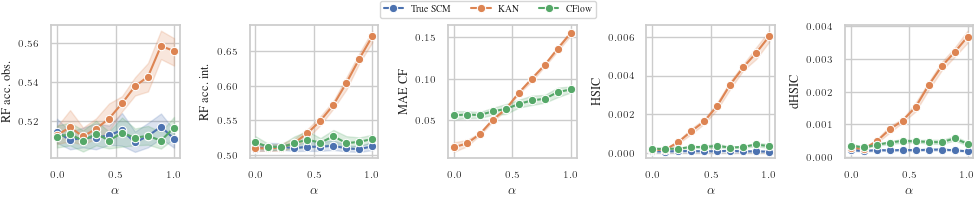

In [32]:
# Single file for later re-plotting.
out_path = str(get_experiment_paths("sensitivity").data / "sensitivity_analysis_results.csv")

# Optional: also save a pickle if you prefer (not needed for plotting).
# with open("sensitivity_analysis_results.pkl", "wb") as f:
#     pickle.dump(df, f)

# ---- plotting (load from disk so style changes do not require re-running) ----
df_plot = pd.read_csv(out_path)

# map the names: MMD obs, RF obs, MMD int, RF int, ATE error, CF MAE, CF MSE, HSIC, dHSIC
metrics_map = {
    "mmd_obs": "MMD obs",
    "rf_obs": "RF acc. obs.",
    "mmd_int": "MMD int",
    "rf_int": "RF acc. int.",
    "ate_error": "ATE error",
    "cf_mae": "MAE CF",
    "cf_mse": "MSE CF",
    "hsic": "HSIC",
    "dhsic": "dHSIC",
}
df_plot["metric"] = df_plot["metric"].map(metrics_map)

# change names of model: KANSCM -> KAN, CFLow -> Flow, orig -> Data
model_map = {
    "kan": "KAN",
    "flow": "CFlow",
    "orig": "True SCM",
}
df_plot["model"] = df_plot["model"].map(model_map)

# in order: data, kan, flow
model_order = ["True SCM", "KAN", "CFlow"]
df_plot["model"] = pd.Categorical(df_plot["model"], categories=model_order, ordered=True)

sns.set_theme(style="whitegrid")
metrics_to_plot= ["RF acc. obs.", "RF acc. int.","MAE CF", "HSIC", "dHSIC"]

with plt.rc_context({**bundles.neurips2024(ncols=len(metrics_to_plot))}):

    fig, axs = plt.subplots(1, len(metrics_to_plot), figsize=(10, 2), sharex=True)
    for metric in metrics_to_plot:
        ax = axs[metrics_to_plot.index(metric)]
        sns.lineplot(
            data=df_plot[df_plot["metric"] == metric],
            x="alpha",
            y="value",
            hue="model",
            marker="o",
            ax=ax,
            errorbar=('ci', 95),
        )

    # get legend handles/labels from first axis
    axs[0].legend()
    handles, labels = axs[0].get_legend_handles_labels()
    # remove legends
    for ax in axs:
        ax.legend().remove()

    for ax, metric in zip(axs.flat, metrics_to_plot):
        ax.set_ylabel(metric)
        ax.set_xlabel(r"$\alpha$")
        ax.grid(True)

    # single legend above the plots with frame
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.07),
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.savefig(get_experiment_paths("sensitivity").figures / "sensitivity_analysis_results.pdf", dpi=300, bbox_inches="tight")
    plt.show()